In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from thesis.common.config import TYPE_TEST, TYPE_TRAIN
from thesis.common.logger import setup_logger
from thesis.eta.config import SCENARIOS_SPECS
from thesis.eta.data import load_fcd_dataset, prepare_baseline_trips, preprocess_fcd_dataset
from thesis.eta.eda import (
    plot_average_speed_and_traffic_generation_period_per_hour,
    plot_speed_histogram,
    plot_trips_distances_distribution,
    plot_trips_durations_distribution,
    report_fcd_statistics,
    report_trips_statistics,
)
from thesis.eta.experiment import initialize_experiment, save_model, save_results
from thesis.eta.features import split_features_and_target
from thesis.eta.models import get_baseline_models
from thesis.eta.pipeline import evaluate_predictions, make_predictions, train_model

2025-06-28 15:52:56 - playground - INFO - Starting experiment playground
2025-06-28 15:52:56 - playground - INFO - Starting scenario base
2025-06-28 15:52:56 - thesis.eta.data - INFO - Verifying integrity of existing file: base-train-fcd.csv
2025-06-28 15:52:57 - thesis.eta.data - INFO - File base-train-fcd.csv is available and valid
2025-06-28 15:52:57 - thesis.eta.data - INFO - Loading FCD data from C:\Users\george\Desktop\diploma-thesis\simulation\data\base-train-fcd.csv
2025-06-28 15:53:01 - thesis.eta.data - INFO - Loaded 12419484 rows of FCD data
2025-06-28 15:53:01 - thesis.eta.data - INFO - Verifying integrity of existing file: base-test-fcd.csv
2025-06-28 15:53:02 - thesis.eta.data - INFO - File base-test-fcd.csv is available and valid
2025-06-28 15:53:02 - thesis.eta.data - INFO - Loading FCD data from C:\Users\george\Desktop\diploma-thesis\simulation\data\base-test-fcd.csv
2025-06-28 15:53:07 - thesis.eta.data - INFO - Loaded 12556304 rows of FCD data
2025-06-28 15:53:07 - t

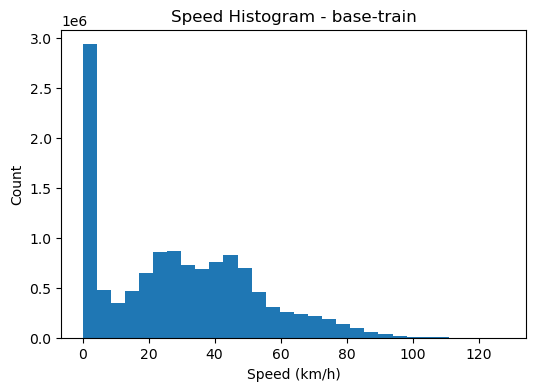

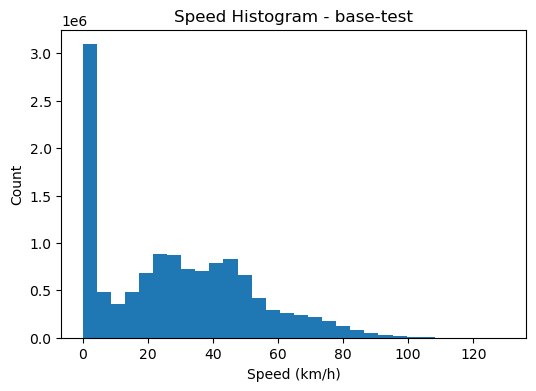

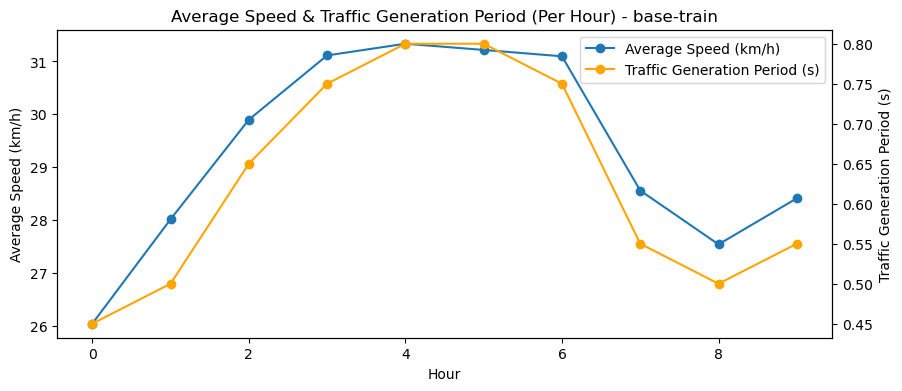

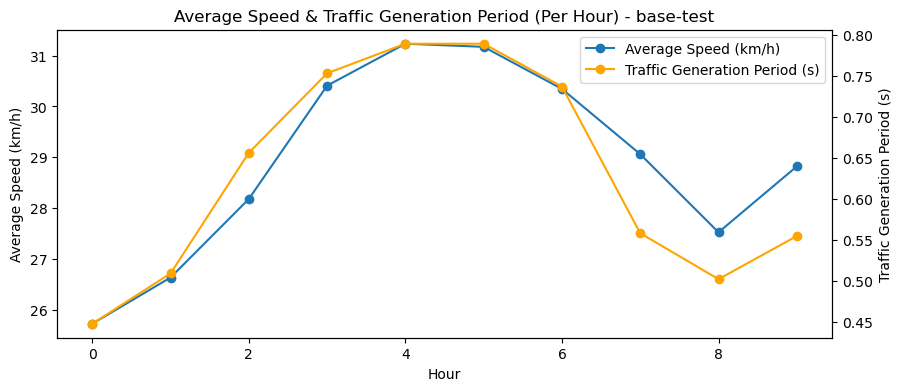

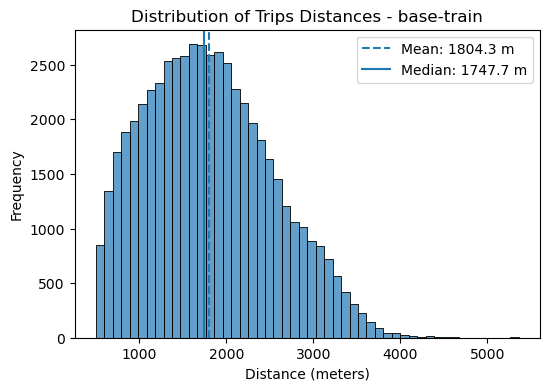

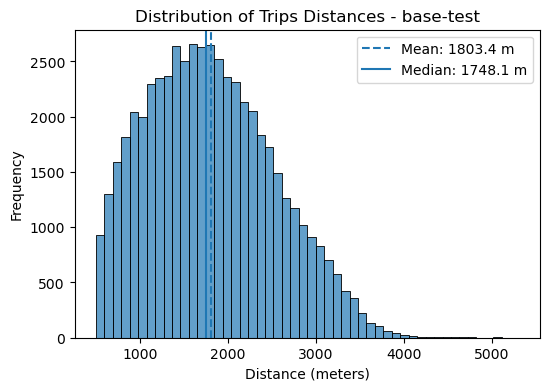

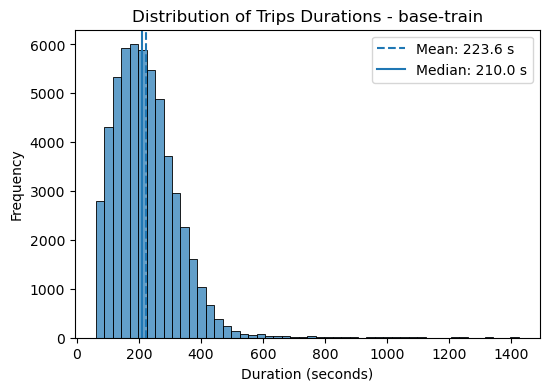

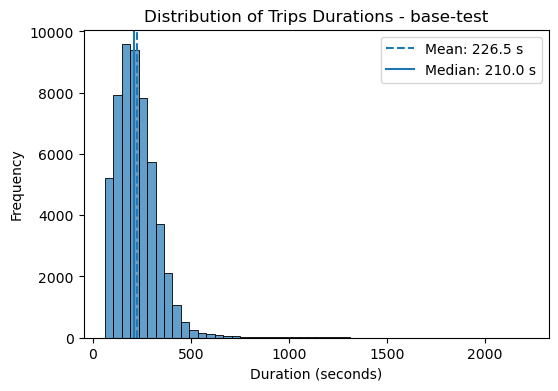

In [4]:
experiment_name = "playground"
artifacts_dir, logs_dir, plots_dir, results_dir = initialize_experiment(experiment_name)
logger = setup_logger(experiment_name, logs_dir)

for scenario_name, train_path, test_path in SCENARIOS_SPECS[0:1]:
    logger.info(f"Starting scenario {scenario_name}")

    train_dataset_id = f"{scenario_name}-{TYPE_TRAIN}"
    test_dataset_id = f"{scenario_name}-{TYPE_TEST}"

    fcd_train = load_fcd_dataset(train_path)
    fcd_test = load_fcd_dataset(test_path)
    fcd_train = preprocess_fcd_dataset(fcd_train)
    fcd_test = preprocess_fcd_dataset(fcd_test)
    trips_train = prepare_baseline_trips(fcd_train)
    trips_test = prepare_baseline_trips(fcd_test)

    report_fcd_statistics(fcd_train, train_dataset_id)
    report_fcd_statistics(fcd_test, test_dataset_id)
    report_trips_statistics(trips_train, train_dataset_id)
    report_trips_statistics(trips_test, test_dataset_id)
    plot_speed_histogram(fcd_train, train_dataset_id, plots_dir)
    plot_speed_histogram(fcd_test, test_dataset_id, plots_dir)
    plot_average_speed_and_traffic_generation_period_per_hour(fcd_train, train_dataset_id, plots_dir)
    plot_average_speed_and_traffic_generation_period_per_hour(fcd_test, test_dataset_id, plots_dir)
    plot_trips_distances_distribution(trips_train, train_dataset_id, plots_dir)
    plot_trips_distances_distribution(trips_test, test_dataset_id, plots_dir)
    plot_trips_durations_distribution(trips_train, train_dataset_id, plots_dir)
    plot_trips_durations_distribution(trips_test, test_dataset_id, plots_dir)

    X_train, y_train = split_features_and_target(trips_train)
    X_test, y_test = split_features_and_target(trips_test)

    models = get_baseline_models()
    results = {}
    for model_name, model in models.items():
        training_results = train_model(model, model_name, X_train, y_train)
        predictions, prediction_results = make_predictions(model, model_name, X_test)
        evaluation_results = evaluate_predictions(y_test, predictions, model_name)

        results[model_name] = {**training_results, **prediction_results, **evaluation_results}
        save_model(model, model_name, scenario_name, artifacts_dir)

    save_results(results, scenario_name, results_dir)